In [1]:
import json

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

import os
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.transforms import v2
import torch.nn as nn

import time
from pathlib import Path

In [2]:
path_to_labels = 'cassava-leaf-disease-classification/train.csv'

df = pd.read_csv(path_to_labels) # Read the labels

# Forming 80/10/10 train, validate, test splits

train_df, temp_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df["label"],
    random_state=42
)

# Ensuring batches are disjoint from one another and that all batches add up to 100%

assert len(train_df) + len(val_df) + len(test_df) == len(df)

assert set(train_df.index).isdisjoint(val_df.index)
assert set(train_df.index).isdisjoint(test_df.index)
assert set(val_df.index).isdisjoint(test_df.index)

class CassavaDataset(Dataset):
    def __init__(self, df, image_dir, transform=None, return_path=False):
        self.df = df.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.return_path = return_path

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image_path = os.path.join(self.image_dir, row["image_id"])

        image = Image.open(image_path).convert("RGB")
        label = int(row["label"])

        if self.transform:
            image = self.transform(image)

        if self.return_path:
            return image, label, image_path

        return image, label

# Setting up transformation initial test

train_transform = v2.Compose([
    v2.RandomResizedCrop(224, scale=(0.8, 1.0)), # Cropping random portion of the input and resizing it. Scale gives lower and upper bound for the crop area
    v2.RandomHorizontalFlip(), # 50% probability that an image is horizontally flipped
    v2.RandomRotation(degrees=15), # Rotates every image by a random degree from [-15, +15]
    v2.ColorJitter( # Randomly changes the brightnes, contrast, saturation of an image
        brightness=0.1, # Brightness factor is jittered uniformly between [max(0, 1-[0.1]), 1 + [0.1]]
        contrast=0.1, # Contrast factor is jittered uniformly between [max(0, 1-[0.1], (1 + [0.1])]
        saturation=0.1, # Saturation factor is jittered uniformly between [max(0, 1-[0.1]), (1+ [0.1])]
    ),
    v2.ToImage(), # Make image a tensor
    v2.ToDtype(torch.float32, scale=True), # Converts image to have datatype float32. We use float32 rather than uint8 since the network needs floating point numbers to correctly operate. Scale move the image from [0, 225] (default uint8 for JPEG) -> [0, 1]
    v2.Normalize(
        mean=[0.485, 0.456, 0.406], # Mean & Std come directly from the ResNet-18 default models
        std=[0.229, 0.224, 0.225]
    )
])

# Setting up validation transformation

val_transform = v2.Compose([
    v2.Resize(256), # Rescaling to (256 * height/width, 256)
    v2.CenterCrop(224), # Crops the image to size (224x224)
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [3]:
def warm_image_cache(directory):
    directory = Path(directory)
    files = list(directory.rglob("*"))
    files = [p for p in files if p.is_file()]

    total_bytes = sum(p.stat().st_size for p in files)

    print(
        f"Warming cache for {len(files):,} files "
        f"({total_bytes / 1024**3:.2f} GiB)..."
    )

    start = time.perf_counter()

    for i, path in enumerate(files, 1):
        with open(path, "rb") as f:
            while f.read(1024 * 1024):
                pass

        if i % 2000 == 0:
            print(f"{i:,}/{len(files):,} files")

    elapsed = time.perf_counter() - start
    print(f"Cache warm-up completed in {elapsed:.1f}s")

image_dir = 'cassava-leaf-disease-classification/train_images'

warm_image_cache(image_dir)

Warming cache for 21,397 files (2.38 GiB)...
2,000/21,397 files
4,000/21,397 files
6,000/21,397 files
8,000/21,397 files
10,000/21,397 files
12,000/21,397 files
14,000/21,397 files
16,000/21,397 files
18,000/21,397 files
20,000/21,397 files
Cache warm-up completed in 18.6s


In [4]:
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

for param in model.parameters():
    param.requires_grad = False

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 5)

# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True)

def training_loop(dataloader, model, loss_fn, optimizer, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.train()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    for batch, (X, y) in enumerate(dataloader):
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.detach() * y.size(0)
        num_correct += (pred.argmax(dim=1) == y).sum()
        num_seen += y.size(0)

        if batch % 100 == 0:
            loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
            print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss / num_seen).item()
        loss_tracker.append(avg_loss)

def validation_loop(dataloader, model, loss_fn, accuracy_tracker = None, loss_tracker = None):
    size = len(dataloader.dataset)
    model.eval()

    total_loss = torch.zeros((), device=device)
    num_correct = torch.zeros((), device=device)
    num_seen = 0

    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            pred = model(X)
            loss = loss_fn(pred, y)

            total_loss += loss.detach() * y.size(0)
            num_correct += (pred.argmax(dim=1) == y).sum()
            num_seen += y.size(0)

            if batch % 100 == 0:
                loss, current = loss.item(), min((batch + 1) * dataloader.batch_size, size)
                print(f"BATCH {batch} -> loss {loss:7f}  [{current:>5f}/{size:>5d}]")

    if accuracy_tracker is not None:
        accuracy = (num_correct / num_seen).item()
        accuracy_tracker.append(accuracy)

    if loss_tracker is not None:
        avg_loss = (total_loss/num_seen).item()
        loss_tracker.append(avg_loss)

# Updating datasets and dataloaders with the transformations
train_dataset = CassavaDataset(train_df, image_dir, train_transform)
val_dataset = CassavaDataset(val_df, image_dir, val_transform)

# Loading the data
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, pin_memory=True, num_workers = 4, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, pin_memory=True, num_workers = 4, persistent_workers=True)

lr = 1e-3

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=lr
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
model = model.to(device)

Using device: cuda


In [5]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

train_loss = []
train_acc = []

val_loss = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_frozen_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

Epoch 1...
BATCH 0 -> loss 2.086416  [32.000000/17117]
BATCH 100 -> loss 0.951139  [3232.000000/17117]
BATCH 200 -> loss 0.921147  [6432.000000/17117]
BATCH 300 -> loss 0.757812  [9632.000000/17117]
BATCH 400 -> loss 0.697848  [12832.000000/17117]
BATCH 500 -> loss 0.847102  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.661964  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.735952  [32.000000/17117]
BATCH 100 -> loss 0.814272  [3232.000000/17117]
BATCH 200 -> loss 0.724374  [6432.000000/17117]
BATCH 300 -> loss 0.685788  [9632.000000/17117]
BATCH 400 -> loss 0.557779  [12832.000000/17117]
BATCH 500 -> loss 1.295145  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.571086  [32.000000/ 2140]
Epoch 3...
BATCH 0 -> loss 0.947258  [32.000000/17117]
BATCH 100 -> loss 0.959731  [3232.000000/17117]
BATCH 200 -> loss 0.863618  [6432.000000/17117]
BATCH 300 -> loss 0.755684  [9632.000000/17117]
BATCH 400 -> loss 0.778075  [12832.000000/17117]
BATCH 500 -> loss 0.839156  [16032.000000/

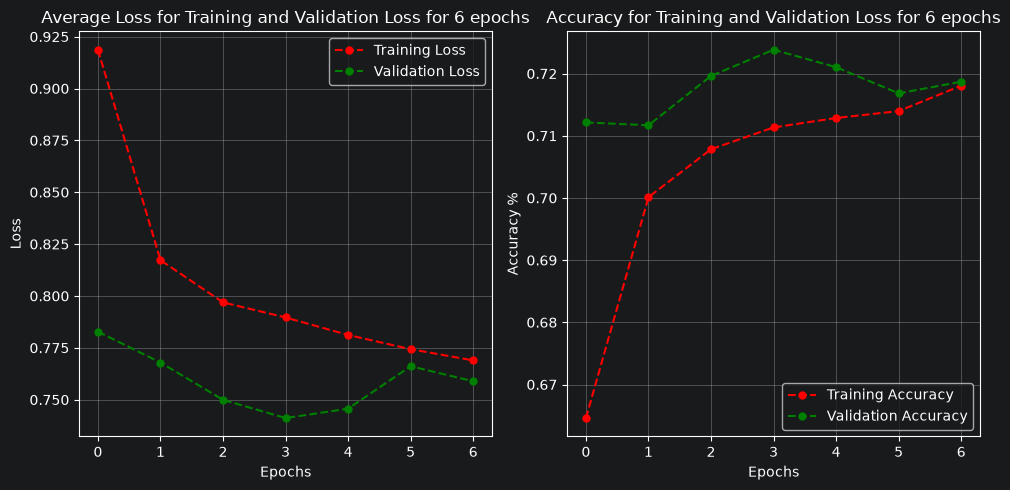

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [7]:
checkpoint = torch.load("best_frozen_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])

for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True # Unfreezing layer 4

for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam([
    {"params": model.layer4.parameters(), "lr": 1e-4},
    {"params": model.fc.parameters(), "lr": 1e-3},
])

In [8]:
epochs = 15
best_val_loss = float("inf")
patience = 3
epochs_without_improvement = 0
min_delta = 1e-4

train_loss = []
train_acc = []

val_loss = []
val_acc = []

for epoch in range(epochs):
    print(f"Epoch {epoch + 1}...")
    training_loop(train_loader, model, criterion, optimizer, accuracy_tracker=train_acc, loss_tracker=train_loss)
    print("Validating...")
    validation_loop(val_loader, model, criterion, accuracy_tracker=val_acc, loss_tracker=val_loss)

    if val_loss[-1] < best_val_loss - min_delta:
        best_val_loss = val_loss[-1]
        epochs_without_improvement = 0
        torch.save({"Epoch": epoch + 1,
                    "model_state_dict": model.state_dict(),
                    "optimizer_state_dict": optimizer.state_dict(),
                    "val_loss": val_loss[-1],
                    "val_accuracy": val_acc[-1]}, "best_finetuned_resnet18.pt")

    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print("Early stopping")
        break

print("Done!")

Epoch 1...
BATCH 0 -> loss 0.633798  [32.000000/17117]
BATCH 100 -> loss 0.662231  [3232.000000/17117]
BATCH 200 -> loss 0.582770  [6432.000000/17117]
BATCH 300 -> loss 0.675997  [9632.000000/17117]
BATCH 400 -> loss 0.720938  [12832.000000/17117]
BATCH 500 -> loss 1.014920  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.562739  [32.000000/ 2140]
Epoch 2...
BATCH 0 -> loss 0.474684  [32.000000/17117]
BATCH 100 -> loss 0.405857  [3232.000000/17117]
BATCH 200 -> loss 0.591026  [6432.000000/17117]
BATCH 300 -> loss 0.373696  [9632.000000/17117]
BATCH 400 -> loss 0.423340  [12832.000000/17117]
BATCH 500 -> loss 0.550793  [16032.000000/17117]
Validating...
BATCH 0 -> loss 0.407272  [32.000000/ 2140]
Epoch 3...
BATCH 0 -> loss 0.307604  [32.000000/17117]
BATCH 100 -> loss 0.884273  [3232.000000/17117]
BATCH 200 -> loss 0.699317  [6432.000000/17117]
BATCH 300 -> loss 0.502887  [9632.000000/17117]
BATCH 400 -> loss 0.578538  [12832.000000/17117]
BATCH 500 -> loss 0.274754  [16032.000000/

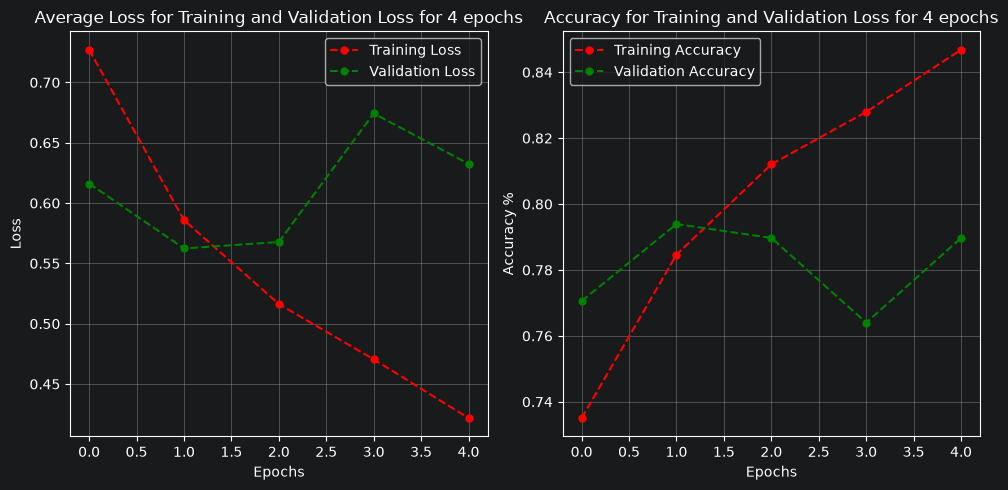

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].plot(train_loss, 'r.--', markersize=10, label='Training Loss')
axs[0].plot(val_loss, 'g.--', markersize=10, label='Validation Loss')
axs[0].set_title(f"Average Loss for Training and Validation Loss for {epoch} epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].grid()
axs[0].legend()

axs[1].plot(train_acc, 'r.--', markersize=10, label='Training Accuracy')
axs[1].plot(val_acc, 'g.--', markersize=10, label='Validation Accuracy')
axs[1].set_title(f"Accuracy for Training and Validation Loss for {epoch} epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accuracy %")
axs[1].grid()
axs[1].legend()

plt.tight_layout()
plt.show()

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

checkpoint = torch.load("best_finetuned_resnet18.pt", weights_only=False)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

all_labels = []
all_preds = []

with torch.no_grad():
    for X, y in val_loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        preds = logits.argmax(dim=1)
        all_labels.extend(y.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

In [39]:
macro_f1 = f1_score(all_labels, all_preds, average='macro')
print(macro_f1)

0.649376899648846


As a quick reminder, we're measuring a few different things in the following cell. Unlike the previous cell where we measure the macro F1 score across all classes, we're going into a class-by-class break down.

Precision is measuring how positive predictions made by the model are correct. Recall is measuring how many positive cases were correctly identified. As mentioned before, the F1 score then tracks the balance between precision and recall with no biases towards either metrics. The classification report also gives us the support for each class. The support is the number of true samples belong to that class.

We are also given the macro average and the weighted averaged. Weighted average gives larger classes more influence where as the macro average treats each class equally.

In [40]:
path_to_classes = 'cassava-leaf-disease-classification/label_num_to_disease_map.json'

with open(path_to_classes, 'r') as f:
    data = json.load(f)

class_names = list(data.values())

for i in range(len(class_names)):
    name = class_names[i]
    class_names[i] = name.split("(")[-1].split(")")[0]

report = classification_report(all_labels, all_preds, target_names=class_names, digits=3)

print(report)

              precision    recall  f1-score   support

         CBB      0.550     0.509     0.529       108
        CBSD      0.675     0.511     0.582       219
         CGM      0.662     0.598     0.629       239
         CMD      0.899     0.931     0.915      1316
     Healthy      0.556     0.636     0.593       258

    accuracy                          0.794      2140
   macro avg      0.668     0.637     0.649      2140
weighted avg      0.790     0.794     0.790      2140



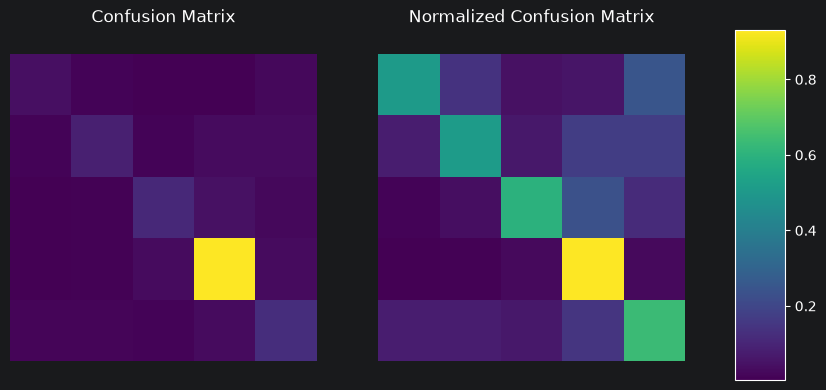

Confusion Matrix:
[[  55   15    5    6   27]
 [  17  112   14   38   38]
 [   3    9  143   56   28]
 [   5   10   38 1225   38]
 [  20   20   16   38  164]]

Normalized Confusion Matrix:
[[0.50925926 0.13888889 0.0462963  0.05555556 0.25      ]
 [0.07762557 0.51141553 0.06392694 0.17351598 0.17351598]
 [0.0125523  0.0376569  0.59832636 0.23430962 0.11715481]
 [0.00379939 0.00759878 0.02887538 0.93085106 0.02887538]
 [0.07751938 0.07751938 0.0620155  0.14728682 0.63565891]]


In [41]:
cm = confusion_matrix(all_labels, all_preds)
cm_normalized = confusion_matrix(all_labels, all_preds, normalize='true')

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

ax[0].matshow(cm, cmap='viridis')
ax[0].set_title('Confusion Matrix')
ax[0].axis('off')

im = ax[1].matshow(cm_normalized, cmap='viridis')
ax[1].set_title('Normalized Confusion Matrix')
ax[1].axis('off')

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(im, cax=cbar_ax)

plt.show()

print(f'Confusion Matrix:\n{cm}\n\nNormalized Confusion Matrix:\n{cm_normalized}')